In [ ]:
 
import nibabel as nb
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, ListedColormap, PowerNorm 
from matplotlib.cm import ScalarMappable
import seaborn as sns
import pandas as pd 
from pathlib import Path

import sys, os
sys.path.append('.../scripts/hippunfold_toolbox')
from hippunfold_toolbox import plotting
import hippunfold_toolbox 
surface_ave = nb.load('...hipp_midthickness.surf.gii')
 

# Plot structures Heritability 

In [ ]:
 # Load heritability values

def load_her_values(df, directory, folder_prefix, file_prefix, columns):

    directory = Path(directory)

    for idx in df.index:
        folder = directory / f"{folder_prefix}{idx}"
        filepath = folder / f"{file_prefix}{idx}.txt"

        hdf = pd.read_csv(filepath, index_col=0)

        for col in columns:
            df.loc[idx, col] = hdf[col].iloc[0]

    return df 

In [ ]:

dirt1t2 = '.../solar_t1wt2w/'

diregyr = '.../solar_gyrific/'

dirsurf = '.../solar_surfarea/'

dirthick = '.../solar_thickness/'

dircurv = '.../solar_curvat/'

In [ ]:
 
df_t1wt2w = pd.DataFrame(index=range(1, 7263), columns=['H2r', 'rp'])
df_t1wt2w.index.name = 'node'


df_t1wt2w = load_her_values(
    df=df_t1wt2w,
    directory=dirt1t2,
    folder_prefix="t1wt2w_",
    file_prefix="herit_node_",
    columns=["H2r", "rp"]
)



df_gyr = pd.DataFrame(index=range(1, 7263), columns=['H2r', 'rp'])
df_gyr.index.name = 'node'


df_gyr = load_her_values(
    df=df_gyr,
    directory=diregyr,
    folder_prefix="gyri_",
    file_prefix="herit_node_",
    columns=["H2r", "rp"]
)



df_surf = pd.DataFrame(index=range(1, 7263), columns=['H2r', 'rp'])
df_surf.index.name = 'node'


df_surf = load_her_values(
    df=df_surf,
    directory=dirsurf,
    folder_prefix="surf_",
    file_prefix="herit_node_",
    columns=["H2r", "rp"]
)






df_thick = pd.DataFrame(index=range(1, 7263), columns=['H2r', 'rp'])
df_thick.index.name = 'node'


df_thick = load_her_values(
    df=df_thick,
    directory=dirthick,
    folder_prefix="thick_",
    file_prefix="herit_node_",
    columns=["H2r", "rp"]
)





df_curv = pd.DataFrame(index=range(1, 7263), columns=['H2r', 'rp'])
df_curv.index.name = 'node'


df_curv = load_her_values(
    df=df_curv,
    directory=dircurv,
    folder_prefix="curv_",
    file_prefix="herit_node_",
    columns=["H2r", "rp"]
)




In [9]:

df_t1wt2w


,H2r,rp
node,,
1,0.248933,0.000293
2,0.255769,0.000385
3,0.184012,0.004293
4,0.179839,0.005875
5,0.216242,0.001383
...,...,...
7258,0.304521,0.000026
7259,0.303184,0.000038
7260,0.191448,0.004929


In [10]:

print(df_t1wt2w['H2r'].max(), df_t1wt2w['H2r'].min(), df_t1wt2w['H2r'].mean(), df_t1wt2w['H2r'].std())

print(df_t1wt2w['rp'].max(), df_t1wt2w['rp'].min(), df_t1wt2w['rp'].mean(), df_t1wt2w['rp'].std())


0.5994802 0.0 0.18464377681818195 0.1062439902624795
0.5 2.5610770000000002e-17 0.06264040062015369 0.11955918361752349


In [11]:



ht1t2 = np.array(df_t1wt2w['H2r'], dtype=float).copy()
print(len(ht1t2))

pt1t2 = np.array(df_t1wt2w['rp'], dtype=float).copy()
len(pt1t2)




hcurv = np.array(df_curv['H2r'], dtype=float).copy()
print(len(hcurv))

pcurv = np.array(df_curv['rp'], dtype=float).copy()
len(pcurv)




hthick = np.array(df_thick['H2r'], dtype=float).copy()
print(len(hthick))

pthick = np.array(df_thick['rp'], dtype=float).copy()
len(pthick)



hsurf = np.array(df_surf['H2r'], dtype=float).copy()
print(len(hsurf))

psurf = np.array(df_surf['rp'], dtype=float).copy()
len(psurf)





hgyr = np.array(df_gyr['H2r'], dtype=float).copy()
print(len(hgyr))

pgyr = np.array(df_gyr['rp'], dtype=float).copy()
len(pgyr)





7262
7262
7262
7262
7262


7262

In [ ]:


print(f"psurf range: {psurf.min()} to {psurf.max()} | Mean: {psurf.mean()}")
print(f"pgyr range: {pgyr.min()} to {pgyr.max()} | Mean: {pgyr.mean()}")
  

psurf range: 1.1771491e-33 to 0.5 | Mean: 0.0010814070311803777
pgyr range: 1.1771491e-33 to 0.5 | Mean: 0.0010814070311841834


In [ ]:
# plot heritability

def plot_surface_metric(surface_ave, metric_data): 
     
    vmin = metric_data.min()
    vmax = metric_data.max()

    norm = Normalize(vmin=vmin, vmax=vmax) 
    fig, ax = plotting.plot_gifti(surface_ave, metric_data)

    mappable = ax.collections[0]

    mappable.set_norm(norm)

    cbar = fig.colorbar(mappable, ax=ax, shrink=0.5) 
    ax.view_init(elev=90, azim=-90)

    plt.show()


## FDR (False Discovery Rate) correction


In [ ]:
 
def FDR(p, q):
    # p : 1D np array, vector of p-values
    # q : float, false discovery rate level
    
    p = np.sort(p)
    
    V = len(p)  
    
    I = np.arange(1,V+1) 
    
    cVID = 1 
    
    cVN  = (1 / np.arange(1,V+1)).sum() # I t’s a normalization constant used for the FDR procedure of Benjamini Yekutiel. 
    # and it adjusts the threshold according to the total number of tests.
    
    pID  = p[np.max(np.where(p <= (I / V*q / cVID)))]
     
    pN   = np.where(p <= (I / V*q / cVN)) 
    
    return pID, pN 



In [ ]:


q = 0.05   

pIDt1t2, pNt1t2 = FDR(pt1t2, q)
 
print("Largest p-value to reject:", pIDt1t2)
print("Indices of rejected hypotheses:", pNt1t2) 


Largest p-value to reject: 0.0344064
Indices of rejected hypotheses: (array([   0,    1,    2, ..., 2738, 2739, 2740]),)


In [ ]:

pIDt1t2, len(np.where(pt1t2 <= pIDt1t2)[0]) 


(0.0344064, 4999)

In [ ]:
# Define colormap 

bordeaux_to_green = LinearSegmentedColormap.from_list(
    "bordeaux_to_green",
    ["#800020", "#008000"]  # Bordeaux red -> intense green
)

 
norm = PowerNorm(gamma=0.5, vmin=0, vmax=1)   
 
mappable = ScalarMappable(norm=norm, cmap=bordeaux_to_green)
 
plt.colorbar(mappable)
plt.show()

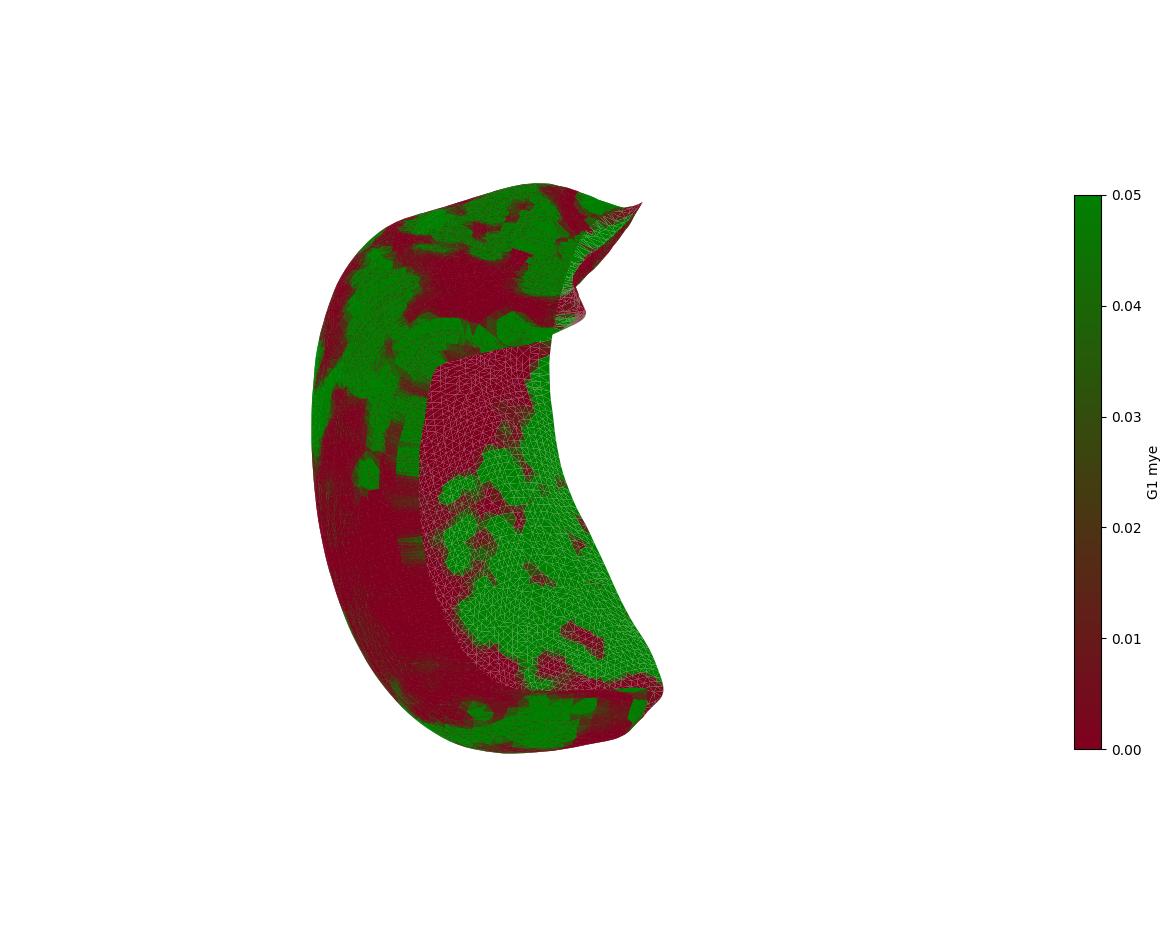

In [ ]:
 
faces = surface_ave.darrays[1].data 
 
face_values = (pt1t2_filled)[faces].mean(axis=1) 

base_cmap = bordeaux_to_green
 
vals = base_cmap(np.linspace(0, 1, 256)) 
my_custom_cmap = ListedColormap(vals) 

fig, ax = plotting.plot_gifti(surface_ave, 'fill', cmap=False) 

mappable = ax.collections[0]  
mappable.set_array(face_values)   
mappable.set_edgecolor('none')  
mappable.set_cmap(my_custom_cmap)

norm = Normalize(vmin=pt1t2_filled.min(), vmax=0.05)
mappable.set_norm(norm)

 
cbar = fig.colorbar(mappable, ax=ax, shrink=0.6)
cbar.set_label("G1 mye")  
ax.view_init(elev=90, azim=-90)
plt.show()


In [ ]:
 
q = 0.05    
pIDcurv, pNcurv = FDR(pcurv, q)  
print("Largest p-value to reject:", pIDcurv)  
print("Indices of rejected hypotheses:", pNcurv)  
 

Largest p-value to reject: 0.0488312
Indices of rejected hypotheses: (array([   0,    1,    2, ..., 7165, 7166, 7167]),)


In [46]:
pcurv

array([4.4366187e-11, 8.0000000e-07, 7.1818645e-09, ..., 4.0000000e-07,
       6.0796000e-12, 1.6500000e-05])

In [ ]:

def plot_fdr_metric(surface_ave, p_values, base_cmap, cbar_label, q=0.05): 
    
    pID, pN = FDR(p_values, q)        
    faces = surface_ave.darrays[1].data 
    
    face_values = (p_values)[faces].mean(axis=1)

    vals = base_cmap(np.linspace(0, 1, 256)) 
    my_custom_cmap = ListedColormap(vals)

    fig, ax = plotting.plot_gifti(surface_ave, 'fill', cmap=False)

    mappable = ax.collections[0] 

    mappable.set_array(face_values) 
 
    mappable.set_edgecolor('none') 

    mappable.set_cmap(my_custom_cmap)
     
    norm = Normalize(vmin=p_values.min(), vmax=q)
    mappable.set_norm(norm)

    cbar = fig.colorbar(mappable, ax=ax, shrink=0.6)
    cbar.set_label(cbar_label) 

    ax.view_init(elev=90, azim=-90)
    plt.show()
 

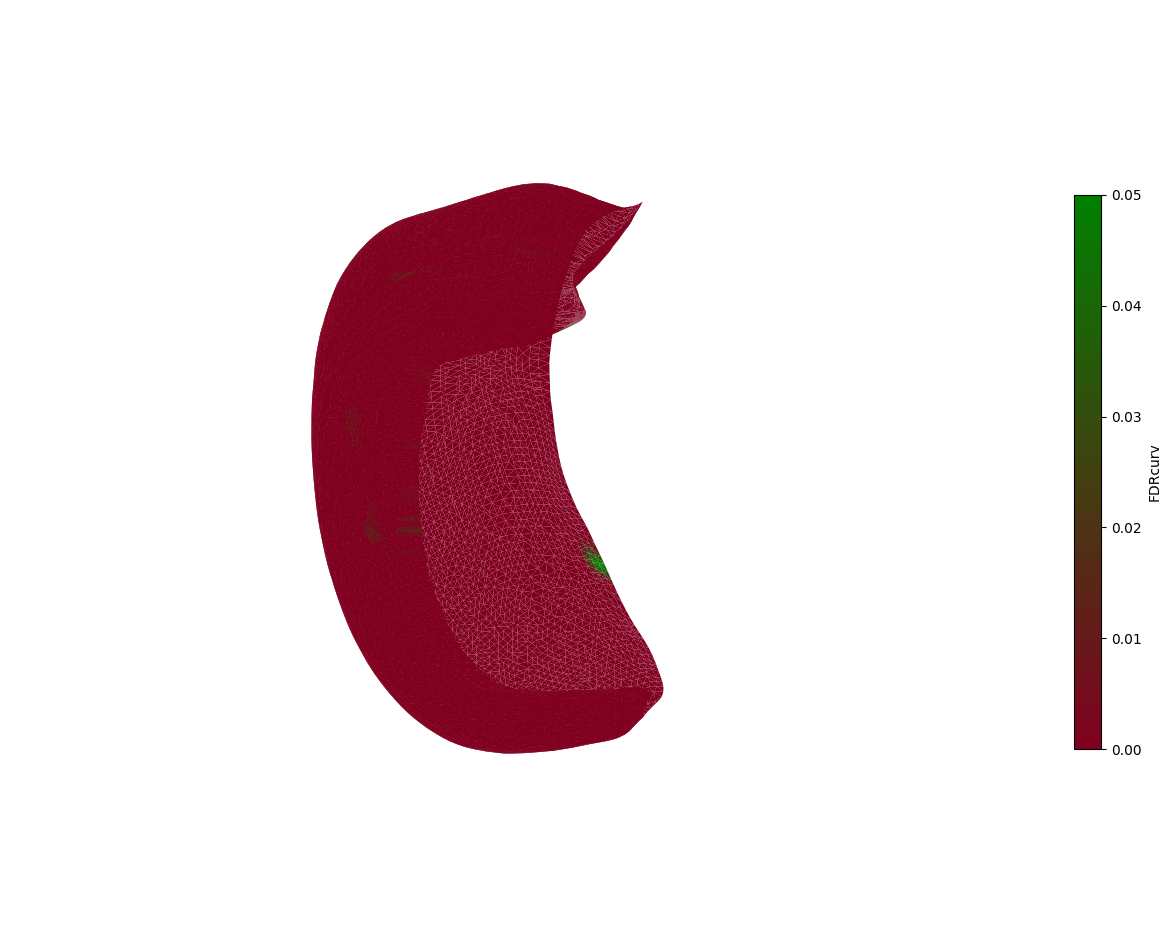

In [ ]:
 
plot_fdr_metric(surface_ave, pcurv, bordeaux_to_green, "FDRcurv", q=0.05) 
